# Jabarulin AI Guided Recommendation System - Technical Specification

Sistem rekomendasi destinasi wisata Jawa Barat menggunakan Artificial Intelligence berbasis model **IndoBERT** (`indobenchmark/indobert-base-p1`) yang di-fine-tune.

## Alur Guided Recommendation
Sistem menggunakan pendekatan terpandu (*guided recommendation*) dua tahap:
1. **Tahap 1 — Memilih Kategori Utama:** Pengguna memilih kategori utama (seperti *Wisata Alam*, *Pantai*, *Keluarga*, *Healing*, dll.) untuk membangun candidate pool secara dinamis menggunakan *soft boosting*. Setiap kategori disertai deskripsi pendukung untuk memandu pengguna.
2. **Tahap 2 — Memasukkan Preferensi Tambahan:** Pengguna memasukkan kueri preferensi tambahan bebas (seperti *"tempat dingin dan tenang di daerah Bogor"*). Sistem memproses kueri, menormalisasi singkatan/typo, memfilter negasi, menyaring daerah/wilayah Jawa Barat, dan memprediksi kecocokan preferensi menggunakan IndoBERT.

## Arsitektur Hybrid Ranking
Skor akhir rekomendasi dihitung berdasarkan formula berikut:
$$\text{Final Score} = 0.50 \times \text{Semantic Similarity} + 0.20 \times \text{Preference Match} + 0.15 \times \text{Category Match} + 0.10 \times \text{Rating Score} + 0.05 \times \text{Popularity Score}$$
Di mana:
- **Semantic Similarity** (bobot 50%): Gabungan dari **TF-IDF similarity (bobot 40%)** pada review dan **IndoBERT embedding similarity (bobot 30%)** pada review.
- **Preference Match** (bobot 20%): Nilai probabilitas kategori preferensi dari model IndoBERT Classifier untuk kategori tempat wisata tersebut berdasarkan kueri preferensi tambahan.
- **Category Match** (bobot 15%): Nilai boost `1.0` jika kategori tempat wisata tersebut sesuai dengan Kategori Utama pilihan user di Tahap 1, dan `0.0` jika berbeda (no hard filter).
- **Rating Score** (bobot 10%): Skor rating objek wisata (skala 0-1).
- **Popularity Score** (bobot 5%): Skor log-scale dari total review objek wisata.

## Fitur & Batasan
- **100% Data Preserved**: Seluruh baris data dari dataset asli `data wisata jawabarat.xlsx` (285 tempat wisata) dipertahankan sepenuhnya.
- **Query Normalization**: Menormalisasi bahasa gaul dan typo bahasa Indonesia sebelum diproses oleh model.
- **Region Filtering**: Secara otomatis mendeteksi nama kota/kabupaten Jawa Barat dalam kueri (Bandung, Bogor, Garut, Pangandaran, dll.) dan menyaring destinasi wisata agar sesuai wilayah tersebut.
- **Negation Handling**: Mendukung negasi (*"jangan pantai"*, *"bukan gunung"*) dengan memfilter nama tempat dan kategori asli secara multi-kolom.
- **No External Generative AI**: Menggunakan IndoBERT lokal hasil training mandiri.

## 1. Setup Environment & Library Imports

In [1]:
!pip install scikit-learn transformers torch openpyxl matplotlib seaborn jinja2 --quiet

import pandas as pd
import numpy as np
import pickle
import os
import re
import random
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
import json

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    set_seed
)

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
set_seed(SEED)

print("Environment dan libraries berhasil dimuat!")


Environment dan libraries berhasil dimuat!


## 2. Dataset Loading & Preprocessing

In [2]:
print("Membaca dataset asli...")
df = pd.read_excel('data wisata jawabarat.xlsx', sheet_name='bersih bersih')
print(f"   Jumlah Data Awal: {len(df)} baris")
print(f"   Kolom yang tersedia: {list(df.columns)}")

df['name'] = df['name'].astype(str).str.title().str.strip()
df['rating'] = pd.to_numeric(df['rating'], errors='coerce').fillna(df['rating'].mean())
df['total_reviews'] = pd.to_numeric(df['total_reviews'], errors='coerce').fillna(0)
df['all_reviews'] = df['all_reviews'].fillna('')
df['cleaned_reviews'] = df['cleaned_reviews'].fillna('')
df['clean_content'] = df['clean_content'].fillna('')
df['category'] = df['category'].fillna('lainnya')

# Memetakan 37 Kategori Google Maps asli ke 8 Kategori Preferensi Wisata (preference_label)
category_to_preference = {
    # wisata_alam
    'tujuan wisata': 'wisata_alam',
    'area rekreasi alam': 'wisata_alam',
    'wisata alam': 'wisata_alam',
    'cagar alam': 'wisata_alam',
    'danau': 'wisata_alam',
    'air terjun': 'wisata_alam',
    'pembangkit listrik': 'wisata_alam',

    # healing
    'pemandian umum luas': 'healing',
    'spa': 'healing',
    'pemandian di ruang terbuka': 'healing',
    'hotel bintang 4': 'healing',
    'pemandian air panas': 'healing',
    'hotel': 'healing',
    'hotel resor': 'healing',
    'hotel bintang 2': 'healing',

    # kuliner (digabung ke wisata_alam karena hanya ada 1 data untuk mencegah error stratify split)
    'produsen makanan': 'wisata_alam',

    # keluarga
    'kolam renang': 'keluarga',
    'kolam renang umum': 'keluarga',
    'event organizer eo': 'keluarga',
    'kebun binatang': 'keluarga',
    'taman': 'keluarga',
    'taman rekreasi air': 'keluarga',

    # adventure
    'area mendaki': 'adventure',
    'pusat olahraga petualangan': 'adventure',
    'rafting': 'adventure',
    'operator wisata rafting': 'adventure',
    'gunung berapi': 'adventure',
    'puncak gunung': 'adventure',
    'jasa sewa kendaraan segala medan': 'adventure',

    # pantai
    'pantai': 'pantai',
    'pantai umum': 'pantai',

    # camping
    'bumi perkemahan': 'camping',
    'kabin perkemahan': 'camping',
    'camp pelatihan': 'camping',
    'camp musim panas anak anak': 'camping',
    'kamp pelatihan': 'camping',
    'kamp musim panas anak anak': 'camping',

    # fotografi
    'titik pemandangan': 'fotografi',
    'bangunan bersejarah': 'fotografi'
}

df['preference_label'] = df['category'].map(category_to_preference).fillna('wisata_alam')

print("\n Distribusi Kolom preference_label:")
print(df['preference_label'].value_counts())
print(f"\nTotal Data Terproses: {len(df)} baris (100% data dipertahankan)")


Membaca dataset asli...
   Jumlah Data Awal: 285 baris
   Kolom yang tersedia: ['name', 'category', 'address', 'phone', 'website', 'rating', 'total_reviews', 'google_maps_url', 'all_reviews', 'cleaned_reviews', 'clean_content']

 Distribusi Kolom preference_label:
preference_label
wisata_alam    179
camping         33
adventure       23
keluarga        19
pantai          18
healing          9
fotografi        4
Name: count, dtype: int64

Total Data Terproses: 285 baris (100% data dipertahankan)


## 3. Training Pipeline (Fine-Tuning IndoBERT)

In [3]:
le = LabelEncoder()
df['preference_encoded'] = le.fit_transform(df['preference_label'])
num_labels = len(le.classes_)
print(f"Mapped Classes: {list(le.classes_)}")

train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df['preference_encoded'],
    random_state=SEED
)
print(f"Data Latih (Train): {len(train_df)} | Data Validasi (Val): {len(val_df)}")

model_name = "indobenchmark/indobert-base-p1"
print(f"\n Memuat tokenizer dan model {model_name}...")
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, num_labels=num_labels)

class TravelDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=64):
        self.texts = texts.reset_index(drop=True)
        self.labels = labels.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            max_length=self.max_len,
            padding=False
        )
        item = {key: torch.tensor(val) for key, val in encoding.items()}
        item['labels'] = torch.tensor(label, dtype=torch.long)
        return item

train_dataset = TravelDataset(train_df['clean_content'], train_df['preference_encoded'], tokenizer)
val_dataset = TravelDataset(val_df['clean_content'], val_df['preference_encoded'], tokenizer)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
print(f" Berjalan menggunakan device: {device}")


Mapped Classes: ['adventure', 'camping', 'fotografi', 'healing', 'keluarga', 'pantai', 'wisata_alam']
Data Latih (Train): 228 | Data Validasi (Val): 57

 Memuat tokenizer dan model indobenchmark/indobert-base-p1...


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

...

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


 Berjalan menggunakan device: cuda


In [4]:
training_args = TrainingArguments(
    output_dir='./results_indobert',
    num_train_epochs=5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_steps=10,
    seed=SEED,
    report_to="none"
)

def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)
    acc = accuracy_score(labels, preds)
    return {'accuracy': acc}

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    processing_class=tokenizer,
    data_collator=data_collator,
    compute_metrics=compute_metrics
)

print(" Memulai Fine-Tuning model IndoBERT Classifier...")
trainer.train()
print(" Fine-Tuning selesai!")

save_path = './models/indobert_classifier'
os.makedirs(save_path, exist_ok=True)
trainer.save_model(save_path)
tokenizer.save_pretrained(save_path)

with open(f"{save_path}/label_encoder.pkl", "wb") as f:
    pickle.dump(le, f)
print(f" Model & Tokenizer berhasil disimpan di folder '{save_path}'!")


 Memulai Fine-Tuning model IndoBERT Classifier...


Epoch,Training Loss,Validation Loss,Accuracy
1,0.791079,0.499108,0.842105
2,0.236412,0.136428,0.982456
3,0.029826,0.113175,0.982456
4,0.008161,0.145046,0.964912
5,0.007344,0.144883,0.964912


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Fine-Tuning selesai!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

 Model & Tokenizer berhasil disimpan di folder './models/indobert_classifier'!


## 4. Evaluasi Model IndoBERT Classifier

 Mengevaluasi model pada validation set...

 Hasil Evaluasi Model:
   Accuracy : 0.9649 (96.49%)
   Precision: 0.9749 (97.49%)
   Recall   : 0.9649 (96.49%)
   F1 Score : 0.9665 (96.65%)

 Classification Report Detail:
              precision    recall  f1-score   support

   adventure       0.71      1.00      0.83         5
     camping       1.00      1.00      1.00         6
   fotografi       1.00      1.00      1.00         1
     healing       1.00      1.00      1.00         2
    keluarga       1.00      0.75      0.86         4
      pantai       1.00      1.00      1.00         3
 wisata_alam       1.00      0.97      0.99        36

    accuracy                           0.96        57
   macro avg       0.96      0.96      0.95        57
weighted avg       0.97      0.96      0.97        57



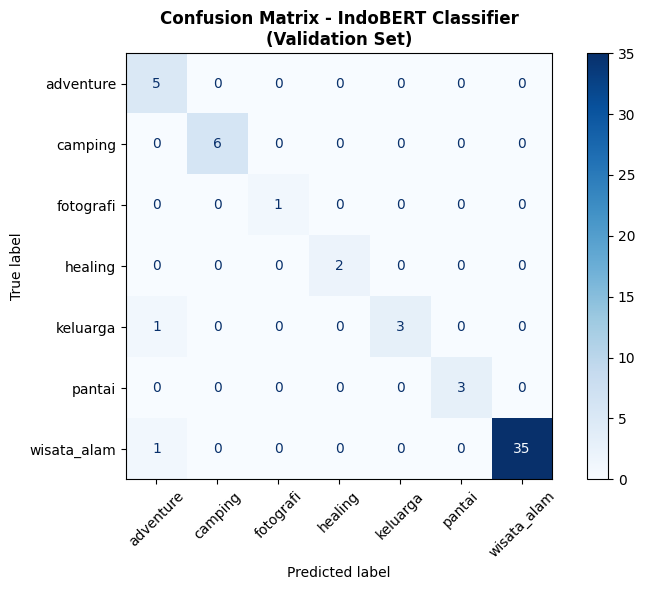

 Confusion matrix disimpan sebagai 'confusion_matrix.png'


In [5]:
print(" Mengevaluasi model pada validation set...")
model.eval()

val_texts = val_df['clean_content'].tolist()
val_labels = val_df['preference_encoded'].tolist()

inputs = tokenizer(
    val_texts,
    padding=True,
    truncation=True,
    max_length=64,
    return_tensors="pt"
).to(device)

with torch.no_grad():
    outputs = model(**inputs)

y_pred = outputs.logits.argmax(dim=-1).cpu().numpy()
y_true = np.array(val_labels)

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("\n Hasil Evaluasi Model:")
print(f"   Accuracy : {accuracy:.4f} ({accuracy*100:.2f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.2f}%)")
print(f"   Recall   : {recall:.4f} ({recall*100:.2f}%)")
print(f"   F1 Score : {f1:.4f} ({f1*100:.2f}%)")

print("\n Classification Report Detail:")
print(classification_report(y_true, y_pred, target_names=le.classes_, zero_division=0))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45, values_format='d')
ax.set_title('Confusion Matrix - IndoBERT Classifier\n(Validation Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print(" Confusion matrix disimpan sebagai 'confusion_matrix.png'")


## 5. Embedding Generation (IndoBERT Encoder)

In [6]:
df['search_text'] = (
    df['all_reviews'].astype(str) + " " +
    df['cleaned_reviews'].astype(str) + " " +
    df['clean_content'].astype(str)
).str.strip()

def extract_indobert_embeddings(texts, model, tokenizer, device, max_len=128, batch_size=16):
    model.eval()
    all_embeddings = []

    bert_backbone = model.bert

    for i in range(0, len(texts), batch_size):
        batch_texts = texts[i : i + batch_size]
        inputs = tokenizer(
            batch_texts,
            padding=True,
            truncation=True,
            max_length=max_len,
            return_tensors="pt"
        ).to(device)

        with torch.no_grad():
            outputs = bert_backbone(**inputs)
            token_embeddings = outputs.last_hidden_state
            attention_mask = inputs['attention_mask']

            input_mask_expanded = attention_mask.unsqueeze(-1).expand(token_embeddings.size()).float()
            sum_embeddings = torch.sum(token_embeddings * input_mask_expanded, 1)
            sum_mask = torch.clamp(input_mask_expanded.sum(1), min=1e-9)
            mean_embeddings = (sum_embeddings / sum_mask).cpu().numpy()

            all_embeddings.append(mean_embeddings)

    return np.vstack(all_embeddings)

print(" Mengekstrak semantic embeddings objek wisata menggunakan IndoBERT Encoder (Mean Pooling)...")
tourism_embeddings = extract_indobert_embeddings(
    df['search_text'].tolist(),
    model,
    tokenizer,
    device,
    max_len=128,
    batch_size=16
)

print(f"   Embeddings selesai! Dimensi matriks: {tourism_embeddings.shape}")
with open(f"{save_path}/tourism_embeddings.pkl", "wb") as f:
    pickle.dump(tourism_embeddings, f)
print(" Embeddings berhasil disimpan di models folder.")


 Mengekstrak semantic embeddings objek wisata menggunakan IndoBERT Encoder (Mean Pooling)...
   Embeddings selesai! Dimensi matriks: (285, 768)
 Embeddings berhasil disimpan di models folder.


## 6. Similarity Search, Negation Handling & Hybrid Ranking

In [7]:
print(" Menginisialisasi TF-IDF Vectorizer...")
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
tfidf_matrix = tfidf_vectorizer.fit_transform(df['search_text'])
print(f"   TF-IDF Matrix Shape: {tfidf_matrix.shape}")

df['rating_score'] = df['rating'] / 5.0
df['popularity_score'] = np.log1p(df['total_reviews'])
scaler = MinMaxScaler()
df['popularity_score'] = scaler.fit_transform(df[['popularity_score']])

class_to_idx = {cls_name: idx for idx, cls_name in enumerate(le.classes_)}

MAIN_CATEGORY_DESCRIPTIONS = {
    "Wisata Alam": "Air Terjun, Danau, Cagar Alam, Bukit",
    "Pantai": "Pantai, Pantai Umum, Pesisir Laut",
    "Camping": "Bumi Perkemahan, Kabin Perkemahan, Glamping",
    "Keluarga": "Kebun Binatang, Kolam Renang, Taman Rekreasi Air, Taman Bermain",
    "Adventure": "Rafting, Offroad, Gunung Berapi, Puncak Gunung, Area Mendaki",
    "Fotografi": "Titik Pemandangan, Bangunan Bersejarah",
    "Healing": "Pemandian Air Panas, Spa, Hotel Resor, Pemandian Terbuka",
    "Lainnya": "Hotel, Produsen makanan, Pembangkit listrik, EO, dll."
}

category_mapping = {
    "wisata alam": "wisata_alam",
    "pantai": "pantai",
    "camping": "camping",
    "keluarga": "keluarga",
    "adventure": "adventure",
    "fotografi": "fotografi",
    "healing / relaksasi": "healing",
    "healing": "healing",
    "lainnya": "wisata_alam"
}

NEGATION_FILTER_KEYWORDS = {
    'pantai': ['pantai', 'beach', 'pesisir'],
    'camping': ['camping', 'camp', 'kemah', 'tenda', 'glamping'],
    'keluarga': ['zoo', 'kebun binatang', 'taman bermain', 'taman rekreasi'],
    'adventure': ['rafting', 'offroad', 'hiking', 'trekking', 'arung jeram', 'mendaki', 'climbing', 'caving'],
    'gunung': ['gunung', 'gn', 'puncak', 'kawah', 'volcano'],
    'healing': ['spa', 'pemandian', 'hot spring', 'hangat'],
    'fotografi': ['titik pemandangan', 'candi', 'monumen', 'sejarah'],
    'kuliner': ['produsen makanan', 'kuliner', 'makanan', 'resto']
}

def normalize_query(query_text):
    query_lower = query_text.lower()
    slang_dict = {
        r'\bpntai\b': 'pantai',
        r'\bcampng\b': 'camping',
        r'\bhiling\b': 'healing',
        r'\bkluarga\b': 'keluarga',
        r'\bfamily\b': 'keluarga',
        r'\bnongki\b': 'nongkrong',
        r'\bnongkrong\b': 'nongkrong',
        r'\badem\b': 'dingin',
        r'\bgw\b': 'saya',
        r'\bgua\b': 'saya',
        r'\bguaa\b': 'saya',
        r'\btmpat\b': 'tempat',
        r'\btpt\b': 'tempat',
        r'\bbgus\b': 'bagus',
        r'\bwisata_alam\b': 'wisata alam',
        r'\bngilangin\b': 'menghilangkan',
        r'\bstress\b': 'stres'
    }
    for slang, formal in slang_dict.items():
        query_lower = re.sub(slang, formal, query_lower)
    query_lower = re.sub(r'\s+', ' ', query_lower).strip()
    return query_lower

def get_negated_categories(query_text):
    query_lower = query_text.lower()
    excluded = []

    negations = ["ga mau", "gak mau", "tidak mau", "bukan", "selain", "jangan", "ga usah", "gak usah", "tanpa", "hindari"]
    keywords_map = {
        "pantai": ["pantai", "laut", "beach", "pesisir"],
        "camping": ["camping", "camp", "kemah", "tenda", "glamping"],
        "keluarga": ["keluarga", "anak", "family", "zoo", "kebun binatang"],
        "adventure": ["adventure", "rafting", "offroad", "hiking", "trekking", "arung jeram", "ekstrem", "ekstrim"],
        "gunung": ["gunung", "puncak", "muncak", "nanjak", "kawah", "mendaki"],
        "healing": ["healing", "hiling", "spa", "pemandian", "rileks", "santai", "sepi", "tenang"],
        "fotografi": ["foto", "fotografi", "pemandangan", "sejara"],
        "kuliner": ["kuliner", "makanan", "kulner", "makan"]
    }

    for neg in negations:
        for match in re.finditer(rf"\b{neg}\b", query_lower):
            start_idx = match.end()
            rest_of_text = query_lower[start_idx:]

            contrast = re.search(r"\b(tapi|tetapi|namun|sedangkan|cuma)\b", rest_of_text)
            if contrast:
                rest_of_text = rest_of_text[:contrast.start()]

            for label, keywords in keywords_map.items():
                for kw in keywords:
                    if kw in rest_of_text:
                        excluded.append(label)
                        break

    return list(set(excluded))

def filter_negated_results(result_df, excluded_labels):
    if not excluded_labels:
        return result_df

    mask = result_df['preference_label'].isin(excluded_labels)

    filter_keywords = []
    for label in excluded_labels:
        if label in NEGATION_FILTER_KEYWORDS:
            filter_keywords.extend(NEGATION_FILTER_KEYWORDS[label])
        filter_keywords.append(label)

    pattern = '|'.join(re.escape(kw) for kw in filter_keywords)

    name_mask = result_df['name'].str.lower().str.contains(pattern, regex=True, na=False)

    category_mask = result_df['category'].str.lower().str.contains(pattern, regex=True, na=False)

    combined_mask = mask | name_mask | category_mask
    return result_df[~combined_mask].copy()

def filter_by_location(result_df, query_text):
    query_lower = query_text.lower()
    regions = [
        'bogor', 'bandung', 'garut', 'pangandaran', 'sukabumi',
        'majalengka', 'subang', 'cianjur', 'kuningan', 'cirebon',
        'tasikmalaya', 'depok', 'bekasi', 'karawang', 'purwakarta', 'sumedang'
    ]

    detected_region = None
    for region in regions:
        if re.search(rf'\b{region}\b', query_lower):
            detected_region = region
            break

    if detected_region:
        loc_pattern = detected_region
        if detected_region == 'bandung':
            loc_pattern = 'bandung|lembang|pangalengan|ciwidey'
        elif detected_region == 'bogor':
            loc_pattern = 'bogor|puncak|sentul'

        loc_mask = (
            result_df['name'].str.lower().str.contains(loc_pattern, regex=True, na=False) |
            result_df['address'].str.lower().str.contains(loc_pattern, regex=True, na=False)
        )
        filtered_df = result_df[loc_mask].copy()
        if not filtered_df.empty:
            print(f" Location Filter: Hanya menampilkan tempat wisata di daerah {detected_region.upper()}")
            return filtered_df
        else:
            print(f" Filter lokasi '{detected_region.upper()}' terdeteksi, namun tidak ditemukan tempat yang cocok di database. Menampilkan semua lokasi.")

    return result_df

def get_hybrid_recommendation(main_category, additional_preference, top_n=5, similarity_threshold=0.0):
    normalized_pref = normalize_query(additional_preference)

    excluded_labels = get_negated_categories(normalized_pref)

    model.eval()
    inputs = tokenizer(
        normalized_pref,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=64
    ).to(device)

    with torch.no_grad():
        outputs = model(**inputs)
        probs = torch.softmax(outputs.logits, dim=-1).flatten().cpu().numpy()

    category_probs = {le.classes_[i]: float(probs[i]) for i in range(len(le.classes_))}
    sorted_probs = sorted(category_probs.items(), key=lambda x: x[1], reverse=True)

    print(f" Tahap 1 - Selected Main Category     : {main_category} (- {MAIN_CATEGORY_DESCRIPTIONS.get(main_category, '')})")
    print(f" Tahap 2 - Raw Preference Query      : {additional_preference}")
    print(f" Tahap 2 - Normalized Preference     : {normalized_pref}")
    print(f" IndoBERT Classifier Probability Boosts:")
    for cat_name, prob_val in sorted_probs[:3]:
        print(f"   - {cat_name.upper()}: {prob_val:.4f}")
    if excluded_labels:
        print(f" Excluded Preferences                 : {[lbl.upper() for lbl in excluded_labels]}")

    query_tfidf = tfidf_vectorizer.transform([normalized_pref])
    tfidf_similarities = cosine_similarity(query_tfidf, tfidf_matrix).flatten()

    query_embedding = extract_indobert_embeddings([normalized_pref], model, tokenizer, device, max_len=64)
    indobert_similarities = cosine_similarity(query_embedding, tourism_embeddings).flatten()

    combined_semantic_similarity = (0.40 * tfidf_similarities + 0.30 * indobert_similarities) / 0.70

    results = df.copy()
    results['semantic_similarity'] = combined_semantic_similarity

    results['preference_match'] = results['preference_label'].map(class_to_idx).map(lambda idx: probs[idx] if pd.notna(idx) else 0.0)

    target_category = category_mapping.get(main_category.lower().strip(), "wisata_alam")
    results['category_match'] = (results['preference_label'] == target_category).astype(float)

    if excluded_labels:
        results = filter_negated_results(results, excluded_labels)

    results = filter_by_location(results, normalized_pref)

    results = results[results['semantic_similarity'] >= similarity_threshold].copy()

    if results.empty:
        print(" Tidak ada tempat wisata yang cocok dengan kriteria pencarian.")
        return pd.DataFrame()

    results['final_score'] = (
        0.50 * results['semantic_similarity'] +
        0.20 * results['preference_match'] +
        0.15 * results['category_match'] +
        0.10 * results['rating_score'] +
        0.05 * results['popularity_score']
    )

    results = results.sort_values(by='final_score', ascending=False)
    results = results.drop_duplicates(subset='name', keep='first')

    recommendations = results.head(top_n).copy()

    recommendations['semantic_similarity'] = recommendations['semantic_similarity'].round(4)
    recommendations['preference_match'] = recommendations['preference_match'].round(4)
    recommendations['category_match'] = recommendations['category_match'].round(4)
    recommendations['final_score'] = recommendations['final_score'].round(4)
    recommendations['rating'] = recommendations['rating'].round(1)

    return recommendations


 Menginisialisasi TF-IDF Vectorizer...
   TF-IDF Matrix Shape: (285, 5000)


## 7. System Testing & Output Formatting

In [11]:
test_cases = [
    ("Keluarga", "tempat seru untuk anak-anak"),
    ("Healing", "tempat dingin dan tenang"),
    ("Adventure", "saya mau tempat dingin tapi bukan gunung"),
    ("Pantai", "pantai yang tenang buat healing"),
    ("Adventure", "tempat santai buat refreshing"),
    ("Wisata Alam", "wisata adem yang akses jalannya gampang"),
    ("Fotografi", "tempat buat menikmati sunset yang santai"),
    ("Wisata Alam", "saya mau wisata alam tapi jangan hiking"),
    ("Wisata Alam", "wisata santai yang bukan buat camping"),
    ("Keluarga", "wisata keluarga tapi jangan tempat ekstrim"),
    ("Wisata Alam", "tempat wisata yang ga bikin capek"),
    ("Healing", "gw mau healing yang adem tapi jangan nanjak di garut"),
    ("Adventure", "tempat nongki yang cozy di bandung"),
    ("Adventure", "gua pengen refreshing yang vibesnya enak"),
    ("Wisata Alam", "wisata yang cocok buat ngilangin stress di bogor"),
    ("Adventure", "tempat buat quality time sama doi"),
    ("Adventure", "nongkrong yang viewnya bagus"),
    ("Adventure", "lagi pengen nyari tempat buat nenangin pikiran"),
    ("Adventure", "cape kerja pengen refreshing"),
    ("Wisata Alam", "wisata yang bikin pikiran fresh"),
    ("Keluarga", "tempat buat santai sambil menikmati suasanatmpat hiling yg adem"),
    ("Adventure", "campng yg adem dan murah"),
    ("Keluarga", "wisata yg bgus buat kluarga di bandung"),
    ("Pantai", "pntai yg viewnya bagus"),
    ("Keluarga", "tempat santai buat refreshing"),
]

for category, query in test_cases:
    print("=" * 80)
    recs = get_hybrid_recommendation(category, query, top_n=3)
    print("-" * 80)

    if not recs.empty:
        json_output = []
        for _, row in recs.iterrows():
            item = {
                "name": row['name'],
                "category": row['category'],
                "rating": float(row['rating']),
                "total_reviews": int(row['total_reviews']),
                "semantic_similarity": float(row['semantic_similarity']),
                "final_score": float(row['final_score'])
            }
            json_output.append(item)
        print(json.dumps(json_output, indent=2, ensure_ascii=False))
    else:
        print("Tidak ada rekomendasi.")
    print("=" * 80 + "\n")


 Tahap 1 - Selected Main Category     : Keluarga (- Kebun Binatang, Kolam Renang, Taman Rekreasi Air, Taman Bermain)
 Tahap 2 - Raw Preference Query      : tempat seru untuk anak-anak
 Tahap 2 - Normalized Preference     : tempat seru untuk anak-anak
 IndoBERT Classifier Probability Boosts:
   - KELUARGA: 0.3295
   - ADVENTURE: 0.2336
   - WISATA_ALAM: 0.1139
--------------------------------------------------------------------------------
[
  {
    "name": "Lembang Park Zoo",
    "category": "kebun binatang",
    "rating": 4.7,
    "total_reviews": 26048,
    "semantic_similarity": 0.2582,
    "final_score": 0.4845
  },
  {
    "name": "Kampung Gajah Park Zoo",
    "category": "kebun binatang",
    "rating": 4.7,
    "total_reviews": 1421,
    "semantic_similarity": 0.2523,
    "final_score": 0.4685
  },
  {
    "name": "Taman Safari Indonesia Bogor",
    "category": "kebun binatang",
    "rating": 4.7,
    "total_reviews": 71710,
    "semantic_similarity": 0.2099,
    "final_score": 0

## 8. Exporting Model & Artifacts

In [9]:
print(" Membuat requirements.txt...")
with open("requirements.txt", "w") as f:
    f.write("transformers\ndatasets\ntorch\nscikit-learn\nopenpyxl\npandas\nnumpy\nmatplotlib\nseaborn\n")
print("   requirements.txt berhasil dibuat!")

import shutil
print("\n Mengompres folder models menjadi ZIP...")
shutil.make_archive('jabarulin_indobert_classifier', 'zip', './models')
print("   Folder models berhasil di-ZIP menjadi 'jabarulin_indobert_classifier.zip'!")

try:
    from google.colab import files
    print("\n Memulai download otomatis berkas ke laptop...")
    files.download('jabarulin_indobert_classifier.zip')
    files.download('requirements.txt')
except ImportError:
    print("\n Tidak berjalan di Google Colab. Proses download dilewati. Anda dapat mengunduh berkas secara manual.")


 Membuat requirements.txt...
   requirements.txt berhasil dibuat!

 Mengompres folder models menjadi ZIP...
   Folder models berhasil di-ZIP menjadi 'jabarulin_indobert_classifier.zip'!

 Memulai download otomatis berkas ke laptop...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>